# Análise Exploratória dos Dados - Projeto NLP

Este notebook realiza uma análise inicial dos arquivos na pasta `dados/pdfs`, identificando tipos de arquivos, validando se PDFs são digitais ou imagens, e explorando o manifesto de dados.

In [19]:
# Contagem geral de arquivos na pasta pdfs
import os
from pathlib import Path

path_pdfs = Path('dados/pdfs')
total_files = len([f for f in path_pdfs.rglob('*') if f.is_file()])
print(f'Quantidade total de arquivos (qualquer tipo): {total_files}')

Quantidade total de arquivos (qualquer tipo): 33225


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import fitz  # PyMuPDF
import re
from collections import Counter

sns.set_theme(style="whitegrid")

## 1. Mapeamento de Arquivos
Vamos listar todos os arquivos na pasta e identificar suas extensões e tamanhos.

In [20]:
path_pdfs = Path('dados/pdfs')
files_data = []

for file in path_pdfs.rglob('*'):
    if file.is_file():
        files_data.append({
            'nome': file.name,
            'extensao': file.suffix.lower(),
            'tamanho_mb': file.stat().st_size / (1024 * 1024),
            'caminho': str(file)
        })

df_files = pd.DataFrame(files_data)
print(f"Total de arquivos encontrados: {len(df_files)}")
df_files.head()

Total de arquivos encontrados: 33225


,nome,extensao,tamanho_mb,caminho
0,.gitignore,,0.000076,dados\pdfs\.gitignore
1,01-ANEXO I - 1.2 - Cadastro de agentes_v9.0.pdf,.pdf,0.465034,dados\pdfs\01-ANEXO I - 1.2 - Cadastro de agen...
2,02-ANEXO II - 1.3 - Votos e ContribuiçΣes_v3.0...,.pdf,0.289617,dados\pdfs\02-ANEXO II - 1.3 - Votos e Contrib...
3,03-ANEXO III - 1.4 - Atendimento_v6.0.pdf,.pdf,0.338387,dados\pdfs\03-ANEXO III - 1.4 - Atendimento_v6...
4,04-ANEXO IV - 1.5 - Desligamento da CCEE_v3.0.pdf,.pdf,0.391465,dados\pdfs\04-ANEXO IV - 1.5 - Desligamento da...


In [4]:
# Extração de arquivos compactados
import zipfile
try:
    import rarfile
except ImportError:
    print("Instalando rarfile para suporte a arquivos .rar...")
    !pip install -q rarfile
    import rarfile

def extrair_compactados(diretorio):
    path = Path(diretorio)
    zips = list(path.rglob('*.zip'))
    rars = list(path.rglob('*.rar'))
    
    print(f"Encontrados {len(zips)} arquivos .zip e {len(rars)} arquivos .rar")
    
    for z in zips:
        try:
            with zipfile.ZipFile(z, 'r') as zip_ref:
                zip_ref.extractall(z.parent)
            print(f"[OK] Extraído: {z.name}")
        except Exception as e:
            print(f"[ERRO] Falha ao extrair {z.name}: {e}")

    for r in rars:
        try:
            with rarfile.RarFile(r) as rar_ref:
                rar_ref.extractall(r.parent)
            print(f"[OK] Extraído: {r.name}")
        except Exception as e:
            print(f"[ERRO] Falha ao extrair {r.name}: {e}. (Certifique-se que o unrar está instalado no sistema)")

extrair_compactados('dados/pdfs')

Instalando rarfile para suporte a arquivos .rar...


Encontrados 48 arquivos .zip e 1 arquivos .rar
[OK] Extraído: adsp20211154_base_de_dados.zip


[OK] Extraído: adsp20211698_2.zip
[OK] Extraído: adsp20212428_2.zip


[OK] Extraído: adsp20221182_2.zip


[OK] Extraído: adsp20221425_2.zip
[OK] Extraído: adsp20221772_2.zip
[OK] Extraído: adsp20222852_2.zip
[OK] Extraído: adsp20223424_2.zip
[OK] Extraído: adsp2022485_2.zip
[OK] Extraído: anexos_aren2021920_2.zip
[OK] Extraído: aprt20226764_2.zip


...

[OK] Extraído: aren2016756_2.zip
[OK] Extraído: aren2021946_2.zip


[OK] Extraído: aren2021951_2.zip
[OK] Extraído: aren2021956_2.zip
[OK] Extraído: aren2021958_2.zip
[OK] Extraído: aren2021960_2.zip
[OK] Extraído: aren2021965_2.zip
[OK] Extraído: aren20221003_2.zip


[OK] Extraído: aren20221007_2.zip
[OK] Extraído: aren20221012_2.zip
[OK] Extraído: aren20221049_2.zip
[OK] Extraído: nreh20162098.zip


[OK] Extraído: nreh20162098_1.zip


[OK] Extraído: nreh20162098_2.zip
[ERRO] Falha ao extrair ndsp2016585.rar: Cannot find working tool. (Certifique-se que o unrar está instalado no sistema)


### Distribuição de Tipos de Arquivos

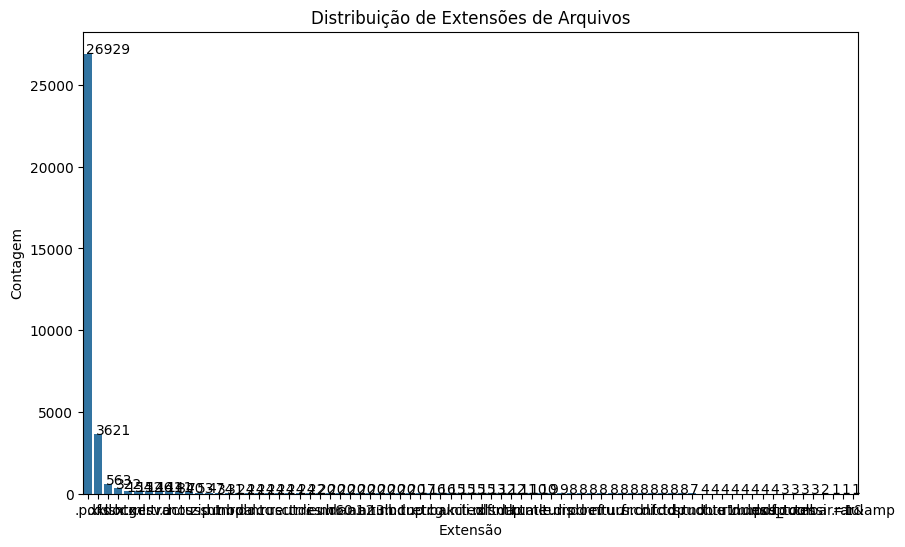

In [21]:
if not df_files.empty:
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(data=df_files, x='extensao', order=df_files['extensao'].value_counts().index)
    plt.title('Distribuição de Extensões de Arquivos')
    plt.xlabel('Extensão')
    plt.ylabel('Contagem')
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x()+0.2, p.get_height()+10))
    plt.show()
else:
    print("Nenhum arquivo encontrado.")

## 2. Análise de PDFs: Digital vs Imagem (OCR)
Um PDF é considerado "digital" se contiver texto extraível. Se não houver texto, provavelmente é uma imagem (scanned).

Analisando amostra de 26929 PDFs...


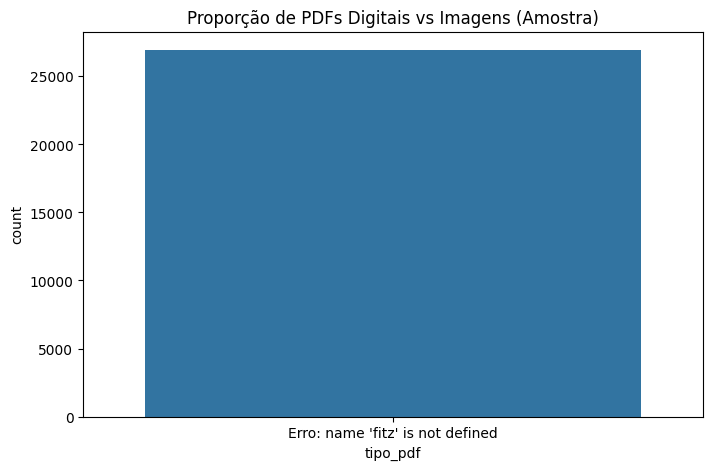

In [22]:
def check_pdf_type(pdf_path):
    try:
        doc = fitz.open(pdf_path)
        text = ""
        for i in range(min(3, len(doc))):
            text += doc[i].get_text()
        doc.close()
        return "Digital" if len(text.strip()) > 50 else "Imagem (Scanned)"
    except Exception as e:
        return f"Erro: {str(e)}"

df_pdfs = df_files[df_files['extensao'] == '.pdf'].copy()
if not df_pdfs.empty:
    sample_size = len(df_pdfs)
    df_sample = df_pdfs.sample(sample_size, random_state=42).copy()
    print(f"Analisando amostra de {sample_size} PDFs...")
    df_sample['tipo_pdf'] = df_sample['caminho'].apply(check_pdf_type)

    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_sample, x='tipo_pdf')
    plt.title('Proporção de PDFs Digitais vs Imagens (Amostra)')
    plt.show()
else:
    print("Nenhum PDF encontrado para análise.")

## Mostra quantos arquivos tem distintos dentro da pasta pdf

In [1]:
from pathlib import Path
from collections import Counter

# Apontando direto para a sua pasta recém-organizada
pasta_alvo = Path("C:\\Users\\User\\Desktop\\Projeto NLP\\dados\\pdfs")

print(f"🔍 Analisando os arquivos em: {pasta_alvo.name}...\n")

try:
    # Cria uma lista pegando apenas a extensão (o finalzinho) de cada arquivo
    # Convertendo para minúsculo (.PDF vira .pdf) para não contar duplicado
    extensoes = [arquivo.suffix.lower() for arquivo in pasta_alvo.iterdir() if arquivo.is_file()]

    if not extensoes:
        print("A pasta está vazia ou não contém arquivos soltos.")
    else:
        # O Counter conta magicamente quantas vezes cada extensão aparece
        contagem = Counter(extensoes)
        
        print("📊 Relatório de Tipos de Arquivos:")
        print("-" * 35)
        
        total_arquivos = 0
        for extensao, quantidade in contagem.most_common():
            # Trata arquivos que por acaso não tenham extensão (ex: arquivos de sistema corrompidos)
            nome_extensao = extensao if extensao else "[Sem extensão]"
            print(f"Tipo: {nome_extensao:<15} | Quantidade: {quantidade}")
            total_arquivos += quantidade
            
        print("-" * 35)
        print(f"Total geral de arquivos: {total_arquivos}")

except FileNotFoundError:
    print(f"Erro: A pasta {pasta_alvo} não foi encontrada. Verifique o caminho.")

🔍 Analisando os arquivos em: pdfs...

📊 Relatório de Tipos de Arquivos:
-----------------------------------
Tipo: .pdf            | Quantidade: 26919
Tipo: .xls            | Quantidade: 1169
Tipo: .xls_1          | Quantidade: 856
Tipo: .xls_2          | Quantidade: 807
Tipo: .xls_3          | Quantidade: 787
Tipo: .xlsx           | Quantidade: 501
Tipo: .docx           | Quantidade: 321
Tipo: .html           | Quantidade: 154
Tipo: .csv            | Quantidade: 68
Tipo: .csv_1          | Quantidade: 60
Tipo: .zip            | Quantidade: 53
Tipo: .xlsx_1         | Quantidade: 39
Tipo: .htm            | Quantidade: 34
Tipo: .ger            | Quantidade: 33
Tipo: .dc             | Quantidade: 32
Tipo: .tra            | Quantidade: 32
Tipo: .nos            | Quantidade: 28
Tipo: .tus            | Quantidade: 27
Tipo: .sut            | Quantidade: 26
Tipo: .ger_1          | Quantidade: 24
Tipo: .dc_1           | Quantidade: 23
Tipo: .tra_1          | Quantidade: 23
Tipo: .nos_1          |

## Concerta os erros e cria novas pastas 

In [5]:
import os
import re
import shutil
import zipfile
from pathlib import Path

# Caminhos das pastas
pasta_alvo = Path("C:\\Users\\User\\Desktop\\Projeto NLP\\dados\\pdfs")
pasta_outros = Path("C:\\Users\\User\\Desktop\\Projeto NLP\\dados\\outros_formatos")
pasta_zips = Path("C:\\Users\\User\\Desktop\\Projeto NLP\\dados\\zips_originais")

# Cria as pastas de destino caso não existam
pasta_outros.mkdir(parents=True, exist_ok=True)
pasta_zips.mkdir(parents=True, exist_ok=True)

print("🚀 Iniciando o Faxineiro de Dados V2 (Anti-Caminho Longo)...\n")

# Função inteligente para não sobrescrever arquivos
def nome_unico_correto(caminho):
    if not caminho.exists():
        return caminho
    i = 1
    while caminho.with_name(f"{caminho.stem}_{i}{caminho.suffix}").exists():
        i += 1
    return caminho.with_name(f"{caminho.stem}_{i}{caminho.suffix}")

# ==========================================
# FASE 1: Corrigir as extensões bugadas
# ==========================================
print("🔧 FASE 1: Verificando extensões...")
padrao_bugado = re.compile(r"^(.*)(\.[a-zA-Z0-9]+)_(\d+)$")

for arquivo in pasta_alvo.iterdir():
    if arquivo.is_file():
        match = padrao_bugado.match(arquivo.name)
        if match:
            nome_base = match.group(1)
            extensao_real = match.group(2)
            numero = match.group(3)
            novo_nome = f"{nome_base}_{numero}{extensao_real}"
            caminho_novo = nome_unico_correto(pasta_alvo / novo_nome)
            arquivo.rename(caminho_novo)

# ==========================================
# FASE 2: Descompactar os arquivos .zip (ATUALIZADA)
# ==========================================
print("\n📦 FASE 2: Descompactando arquivos .zip (Modo Direto)...")
for arquivo in list(pasta_alvo.glob("*.zip")): # Usa list() para não bugar o iterador ao mover arquivos
    try:
        with zipfile.ZipFile(arquivo, 'r') as zip_ref:
            for zip_info in zip_ref.infolist():
                if not zip_info.is_dir(): # Ignora pastas, pega só os arquivos
                    # Pega apenas o nome final do arquivo, ignorando a árvore de pastas gigantesca
                    nome_arquivo = Path(zip_info.filename).name
                    destino_final = nome_unico_correto(pasta_alvo / nome_arquivo)
                    
                    # Lê os bytes de dentro do zip e escreve direto na pasta raiz
                    with zip_ref.open(zip_info) as source, open(destino_final, "wb") as target:
                        shutil.copyfileobj(source, target)
                        
        # Move o arquivo .zip original para o backup
        shutil.move(str(arquivo), str(pasta_zips / arquivo.name))
        print(f"   -> {arquivo.name} descompactado com sucesso!")
        
    except zipfile.BadZipFile:
        print(f"   ❌ Erro: O arquivo {arquivo.name} parece corrompido ou protegido por senha.")
    except Exception as e:
        print(f"   ❌ Erro inesperado em {arquivo.name}: {e}")

# ==========================================
# FASE 3: Mover tudo que não é PDF
# ==========================================
print("\n🧹 FASE 3: Separando arquivos que não são PDF...")
contador_movidos = 0

# Pega todos os arquivos da pasta alvo novamente (incluindo os que acabaram de sair dos zips)
for arquivo in pasta_alvo.iterdir():
    if arquivo.is_file() and arquivo.suffix.lower() != ".pdf":
        destino_outros = nome_unico_correto(pasta_outros / arquivo.name)
        shutil.move(str(arquivo), str(destino_outros))
        contador_movidos += 1

print(f"\n🎉 SUCESSO! A faxina terminou.")
print(f"➡️ Arquivos movidos para a pasta 'outros_formatos': {contador_movidos}")

🚀 Iniciando o Faxineiro de Dados V2 (Anti-Caminho Longo)...

🔧 FASE 1: Verificando extensões...

📦 FASE 2: Descompactando arquivos .zip (Modo Direto)...

🧹 FASE 3: Separando arquivos que não são PDF...

🎉 SUCESSO! A faxina terminou.
➡️ Arquivos movidos para a pasta 'outros_formatos': 14


In [6]:
from pathlib import Path
from collections import Counter

# Mapeamento das suas pastas
pastas_para_analisar = {
    "PDFs Limpos (Prontos para IA)": Path("C:\\Users\\User\\Desktop\\Projeto NLP\\dados\\pdfs"),
    "Outros Formatos (Planilhas, Textos, etc)": Path("C:\\Users\\User\\Desktop\\Projeto NLP\\dados\\outros_formatos"),
    "ZIPs de Backup": Path("C:\\Users\\User\\Desktop\\Projeto NLP\\dados\\zips_originais")
}

print("📊 RELATÓRIO FINAL DO BANCO DE DADOS\n" + "="*50)

total_geral_arquivos = 0

for nome_pasta, caminho in pastas_para_analisar.items():
    if not caminho.exists():
        print(f"⚠️ A pasta não foi encontrada: {caminho}")
        continue

    # Pega a extensão de todos os arquivos dentro da pasta
    extensoes = [arquivo.suffix.lower() if arquivo.suffix else "[Sem extensão]" 
                 for arquivo in caminho.iterdir() if arquivo.is_file()]
    
    total_pasta = len(extensoes)
    total_geral_arquivos += total_pasta
    contagem = Counter(extensoes)

    print(f"\n📁 {nome_pasta}")
    print(f"Caminho: {caminho.name}")
    print(f"Total na pasta: {total_pasta} arquivos")
    print("-" * 35)
    
    if total_pasta == 0:
        print("  (Pasta vazia)")
    else:
        # Imprime as extensões ordenadas pela quantidade
        for ext, qtd in contagem.most_common():
            print(f"  {ext:<15} : {qtd} arquivo(s)")

print("\n" + "="*50)
print(f"🎯 TOTAL GERAL DE ARQUIVOS NO PROJETO: {total_geral_arquivos}")
print("="*50)

📊 RELATÓRIO FINAL DO BANCO DE DADOS

📁 PDFs Limpos (Prontos para IA)
Caminho: pdfs
Total na pasta: 27121 arquivos
-----------------------------------
  .pdf            : 27121 arquivo(s)

📁 Outros Formatos (Planilhas, Textos, etc)
Caminho: outros_formatos
Total na pasta: 15064 arquivos
-----------------------------------
  .xls            : 9270 arquivo(s)
  .xlsx           : 1071 arquivo(s)
  .docx           : 644 arquivo(s)
  .ger            : 394 arquivo(s)
  .dc             : 370 arquivo(s)
  .tra            : 370 arquivo(s)
  .csv            : 308 arquivo(s)
  .nos            : 208 arquivo(s)
  .tus            : 180 arquivo(s)
  .html           : 154 arquivo(s)
  .sut            : 134 arquivo(s)
  .nbd            : 74 arquivo(s)
  .ddc            : 60 arquivo(s)
  .ntc            : 60 arquivo(s)
  .reu            : 60 arquivo(s)
  .rpa            : 60 arquivo(s)
  .tdi            : 60 arquivo(s)
  .ctr            : 56 arquivo(s)
  .rus            : 56 arquivo(s)
  .res            